# Self-Routing Between Retrieval Strategies [Step 04 - Self-Routing]

> **MLCourse - Agentic AI - Autonomous RAG**

Standard RAG uses a single retriever and hopes for the best.  Autonomous RAG
starts by letting the LLM **decide** which retrieval strategy fits the query
before touching the index.  This notebook builds a LangGraph that classifies
every incoming question into one of three strategies -- vector search, keyword
(BM25) search, or a direct LLM answer that skips retrieval entirely -- and
routes accordingly.

### What you will learn

1. How to build a classifier node that picks a retrieval strategy at runtime.
2. How vector and BM25 retrievers differ on the same corpus.
3. When retrieval should be skipped entirely (the LLM already knows).
4. How conditional edges wire the three branches into one graph.

## 1. Setup

In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## 2. Ingest and Chunk Alice

In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

# Split on chapter boundaries, then chunk within each chapter
marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

print(f"[ingest] chunks: {len(documents)}")

[ingest] chunks: 60


## 3. Build Both Retrievers
We create a vector retriever (FAISS with MiniLM embeddings) and a BM25
keyword retriever from the same document list.  Each wraps behind the
standard LangChain retriever interface so the graph can call them
interchangeably.

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever

# --- vector retriever ---
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
vector_retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print("[retriever] vector (FAISS) ready, k=4")

# --- BM25 keyword retriever ---
bm25_retriever = BM25Retriever.from_documents(documents, k=4)
print("[retriever] BM25 ready, k=4")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[retriever] vector (FAISS) ready, k=4
[retriever] BM25 ready, k=4


## 4. Initialize the LLM

In [4]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


## 5. Define the State
The state tracks the query, which strategy was chosen, the retrieved context
(if any), the final answer, and a log of every routing decision made.

In [5]:
from typing import TypedDict

class RoutingState(TypedDict):
    query: str                       # original user question
    strategy: str                    # "vector", "bm25", or "direct"
    context: str                     # retrieved text joined together
    answer: str                      # final generated answer
    route_log: list                  # list of routing decisions for inspection

print("[state] RoutingState defined")

[state] RoutingState defined


## 6. Strategy Classifier Node
The LLM reads the query and returns exactly one label.  A safety fallback
maps any unexpected output to "vector" so the graph never dead-ends.

In [6]:
def classify_strategy(state: RoutingState) -> dict:
    """Ask the LLM which retrieval strategy best fits the query."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a retrieval-strategy classifier for a book about Alice in Wonderland. "
         "Classify the user query into EXACTLY one word:\n"
         "- 'vector' if it is a semantic or conceptual question about the story\n"
         "- 'bm25' if it contains a specific name, place, or exact phrase to look up\n"
         "- 'direct' if the answer is common knowledge and needs no document\n"
         "Reply with ONLY the label."),
        ("user", "{query}")
    ])
    response = (prompt | llm).invoke({"query": state["query"]})
    label = response.content.strip().lower()
    if label not in ("vector", "bm25", "direct"):
        label = "vector"               # safe default
    log = state.get("route_log", []) + [f"classifier -> {label}"]
    print(f"  [classify] strategy: {label}")
    return {"strategy": label, "route_log": log}

## 7. Three Strategy Nodes

In [7]:
def retrieve_vector(state: RoutingState) -> dict:
    """Retrieve chunks via vector similarity search."""
    docs = vector_retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    log = state.get("route_log", []) + [f"vector retrieved {len(docs)} chunks"]
    print(f"  [vector] retrieved {len(docs)} chunks")
    return {"context": context, "route_log": log}


def retrieve_bm25(state: RoutingState) -> dict:
    """Retrieve chunks via BM25 keyword search."""
    docs = bm25_retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    log = state.get("route_log", []) + [f"bm25 retrieved {len(docs)} chunks"]
    print(f"  [bm25] retrieved {len(docs)} chunks")
    return {"context": context, "route_log": log}


def direct_answer(state: RoutingState) -> dict:
    """Answer directly from LLM knowledge (no retrieval)."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Answer the question concisely in 1-3 sentences using your own knowledge. "
         "Do NOT fabricate book details."),
        ("user", "{query}")
    ])
    response = (prompt | llm).invoke({"query": state["query"]})
    log = state.get("route_log", []) + ["direct answer (no retrieval)"]
    print(f"  [direct] answered from LLM knowledge")
    return {"answer": response.content, "context": "", "route_log": log}

## 8. Answer Generator Node
Used by both retrieval branches to produce a grounded answer from context.

In [8]:
def generate_answer(state: RoutingState) -> dict:
    """Generate an answer grounded in the retrieved context."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Answer the question using ONLY the provided context. "
         "If the context does not contain enough information, say so. "
         "Keep the answer to 2-4 sentences."),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (prompt | llm).invoke({
        "query": state["query"],
        "context": state["context"]
    })
    print(f"  [generate] answer length: {len(response.content)} chars")
    return {"answer": response.content}

## 9. Build the Self-Routing Graph
The classifier node sits at the top.  Three conditional edges fan out to the
three strategy nodes.  Vector and BM25 both feed into the shared generator;
the direct branch bypasses it entirely.

In [9]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(RoutingState)

# Nodes
graph.add_node("classify", classify_strategy)
graph.add_node("retrieve_vector", retrieve_vector)
graph.add_node("retrieve_bm25", retrieve_bm25)
graph.add_node("direct_answer", direct_answer)
graph.add_node("generate", generate_answer)

# Entry
graph.add_edge(START, "classify")

# Routing function
def route_strategy(state: RoutingState) -> str:
    """Pick the next node based on the classified strategy."""
    return f"retrieve_{state['strategy']}" if state["strategy"] != "direct" else "direct_answer"

graph.add_conditional_edges(
    "classify",
    route_strategy,
    {
        "retrieve_vector": "retrieve_vector",
        "retrieve_bm25": "retrieve_bm25",
        "direct_answer": "direct_answer",
    }
)

# Retrieval branches converge on the generator
graph.add_edge("retrieve_vector", "generate")
graph.add_edge("retrieve_bm25", "generate")

# Generator and direct both end
graph.add_edge("generate", END)
graph.add_edge("direct_answer", END)

app = graph.compile()
print("[graph] self-routing graph compiled")

[graph] self-routing graph compiled


## 10. Visualize the Graph

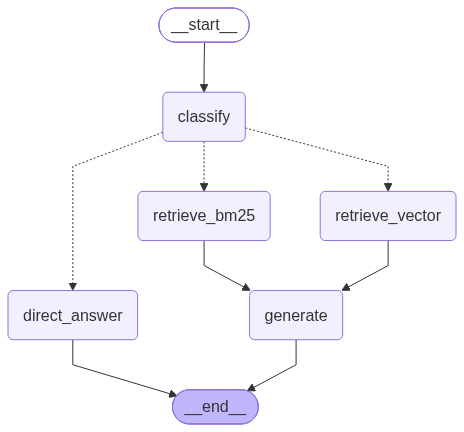

In [10]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> classify")
    print("    classify -> retrieve_vector -> generate -> END")
    print("    classify -> retrieve_bm25   -> generate -> END")
    print("    classify -> direct_answer               -> END")

## 11. Test: Semantic Question (should route to vector)

In [11]:
print("=" * 60)
print("TEST 1: Semantic question -> expect 'vector'")
print("=" * 60)
result = app.invoke({
    "query": "What is the story about emotionally? What are the main themes?",
    "context": "",
    "answer": "",
    "route_log": [],
})
print(f"\nStrategy chosen: {result['strategy']}")
print(f"Answer: {result['answer'][:300]}")
print(f"Route log: {result['route_log']}")

TEST 1: Semantic question -> expect 'vector'


  [classify] strategy: vector
  [vector] retrieved 4 chunks


  [generate] answer length: 309 chars

Strategy chosen: vector
Answer: The story is about Alice's emotional struggles with frustration, self-doubt, and self-criticism. The main themes are the consequences of negative self-talk and the importance of self-compassion. Alice's inner dialogue reveals her tendency to scold herself harshly, which leads to tears and emotional 
Route log: ['classifier -> vector', 'vector retrieved 4 chunks']


## 12. Test: Specific Name Lookup (should route to BM25)

In [12]:
print("=" * 60)
print("TEST 2: Specific name query -> expect 'bm25'")
print("=" * 60)
result = app.invoke({
    "query": "What did the Cheshire Cat say to Alice?",
    "context": "",
    "answer": "",
    "route_log": [],
})
print(f"\nStrategy chosen: {result['strategy']}")
print(f"Answer: {result['answer'][:300]}")
print(f"Route log: {result['route_log']}")

TEST 2: Specific name query -> expect 'bm25'


  [classify] strategy: bm25
  [bm25] retrieved 4 chunks


  [generate] answer length: 64 chars

Strategy chosen: bm25
Answer: There is no mention of the Cheshire Cat in the provided context.
Route log: ['classifier -> bm25', 'bm25 retrieved 4 chunks']


## 13. Test: Common Knowledge (should route to direct)

In [13]:
print("=" * 60)
print("TEST 3: Common knowledge -> expect 'direct'")
print("=" * 60)
result = app.invoke({
    "query": "Who wrote Alice in Wonderland?",
    "context": "",
    "answer": "",
    "route_log": [],
})
print(f"\nStrategy chosen: {result['strategy']}")
print(f"Answer: {result['answer'][:300]}")
print(f"Route log: {result['route_log']}")

TEST 3: Common knowledge -> expect 'direct'


  [classify] strategy: direct


  [direct] answered from LLM knowledge

Strategy chosen: direct
Answer: Alice's Adventures in Wonderland was written by Lewis Carroll, whose real name was Charles Lutwidge Dodgson.
Route log: ['classifier -> direct', 'direct answer (no retrieval)']


## 14. Inspect Graph Structure

In [14]:
print("=== Graph Structure ===")
g = app.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print(f"Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'classify', 'retrieve_vector', 'retrieve_bm25', 'direct_answer', 'generate', '__end__']
Edges:
  __start__ -> classify
  classify -> direct_answer
  classify -> retrieve_bm25
  classify -> retrieve_vector
  retrieve_bm25 -> generate
  retrieve_vector -> generate
  direct_answer -> __end__
  generate -> __end__


## Summary

Key takeaways:
- The classifier node reads every query and picks the best retrieval strategy.
- Vector search excels at semantic/conceptual questions.
- BM25 excels at exact name and phrase lookups.
- Some questions need no retrieval at all; the LLM can answer directly.
- All three branches are wired into a single graph with conditional edges.
- Self-routing avoids wasting tokens on irrelevant retrievals and improves
  answer quality by matching strategy to query type.